In [107]:

pip install TypedDict

In [1]:
from typing import Dict,TypedDict

In [19]:
from langgraph.graph import StateGraph,START,END

In [110]:
!pip install -U langgraph

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
  Attempting uninstall: pydantic
    Found existing installation: pydantic 1.10.26
    Uninstalling pydantic-1.10.26:
      Successfully uninstalled pydantic-1.10.26
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typeddict 0.3.0 requires pydantic<2.0.0,>=1.9.1, but you have pydantic 2.13.4 which is incompatible.


In [4]:
class AgentState(TypedDict):#our staeteschema
  message :str
def greeting_node(state:AgentState) -> AgentState:
  """ simple node that adds a greeting"""
  state['message'] = "hey "+ state ['message'] +", how is your day going?"
  return state


In [5]:
graph =StateGraph(AgentState)
graph.add_node('greeter',greeting_node)
graph.set_entry_point('greeter')
graph.set_finish_point('greeter')
app =graph.compile()


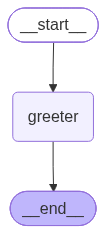

In [6]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
app.invoke({
    'message':'bob'
}
)

{'message': 'hey bob, how is your day going?'}

In [115]:
# multiple inputs graph

In [116]:
from typing import List

In [117]:
class AgentState2(TypedDict):

  values: List[int]
  name:str
  results :str


In [118]:
def process_values(state:AgentState2) -> AgentState:
  """ this fuction proecess handles ,multiplr diffrmet inputs"""
  print(state)
  state['results']=f"hi There {state['name']}! Your sum = {sum(state['values'])}"
  return state
  print(state)

In [119]:
graph2=StateGraph(AgentState2)

graph2.add_node('processor',process_values)
graph2.set_entry_point('processor')
graph2.set_finish_point('processor')

In [120]:
app2=graph2.compile()

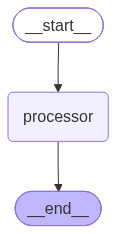

In [121]:
from IPython.display import Image,display
display(Image(app2.get_graph().draw_mermaid_png()))

In [122]:
ans= app2.invoke({
    "values":[1,2,3],
    "name":'anushka'
}

)

{'values': [1, 2, 3], 'name': 'anushka'}


In [123]:
print(ans['results'])

hi There anushka! Your sum = 6


In [124]:
class Agent(TypedDict):
  values:list[int]
  name:str
  operation :str

In [125]:
def calculate_node(state:Agent) -> Agent:

  if state['operation']== "+":
    result=sum(state['values'])
  elif state['operation']=='*':
    result=1
    for value in state['values']:
      result =result * value
    state['message']=f'hi {state['name']} , your answer is : {result}'
    return state


In [126]:
graph3=StateGraph(Agent)
graph3.add_node("calculator",calculate_node)
graph3.set_entry_point('calculator')
graph3.set_finish_point('calculator')


In [127]:
app3=graph3.compile()

In [128]:
result=app3.invoke({
    'name': "jack sparrow",
    'values':[1,2,3],
    'operation':'*'
}
)

In [129]:
print(result)

{'values': [1, 2, 3], 'name': 'jack sparrow', 'operation': '*'}


In [130]:
 #sequential graph

In [20]:
class AgentState6(TypedDict):
  name:str
  age:int
  final:str

In [23]:
def first_node(state :AgentState6) -> AgentState6 :

  """ sequemtial garpgh"""
  state['final']=f"hi {state['name']}"
  return state
def second_node(state:AgentState6) -> AgentState6:
  """ second node of the sequnece"""
  state['final']=state['final'] + f"you are {state['age']} years old"
  return state



In [25]:
graph6= StateGraph(AgentState6)
graph6.add_node("first_node",first_node)
graph6.add_node("second_node",second_node)
graph6.set_entry_point('first_node')
# if i want to add node 1 with node2 we use edge.

graph6.add_edge("first_node","second_node")
graph6.set_finish_point('second_node')

In [26]:
app6=graph6.compile()

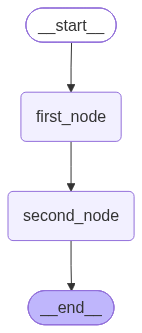

In [27]:
from IPython.display import Image,display
display(Image(app6.get_graph().draw_mermaid_png()))

In [28]:
result=app6.invoke(
    {'name' : 'Anushka',
     'age': 20
     }
)

In [29]:
print(result)

{'name': 'Anushka', 'age': 20, 'final': 'hi Anushkayou are 20years old'}


In [3]:
#ex3
class Agentexp3(TypedDict):
  name: str
  age: int
  skills:list[str]
  result:str

In [4]:
def first_node1(state:Agentexp3) -> Agentexp3:
  """ first node"""
  state['result']=f"{state['name']} welcome to the system !"
  return state
def second_node(state:Agentexp3) -> Agentexp3:
  """ second node"""
  state['result']=state['result'] + f'you are {state['age']} years old!'
  return state
def third_node(state:Agentexp3) -> Agentexp3:
  """ third node"""
  state['result']=state['result'] + f'you have skills in : {state['skills']}'
  return state

In [10]:
graphexp=StateGraph(Agentexp3)
graphexp.add_node("first_nodeanu",first_node1)
graphexp.add_node("second_nodeanu",second_node)
graphexp.add_node("third_node",third_node)
graphexp.set_entry_point('first_nodeanu')
graphexp.add_edge("first_nodeanu","second_nodeanu")
graphexp.add_edge("second_nodeanu","third_node")
graphexp.set_finish_point('third_node')

In [11]:
appexp=graphexp.compile()

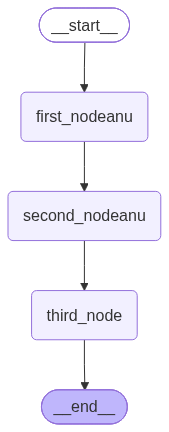

In [12]:
from IPython.display import Image,display
display(Image(appexp.get_graph().draw_mermaid_png()))

In [17]:
result=appexp.invoke({
    "name":'Anushka',
    "age":20,
    "skills":['python','java'],
    'results': ""
}
)

In [18]:
print(result)

{'name': 'Anushka', 'age': 20, 'skills': ['python', 'java'], 'result': "Anushka welcome to the system !you are 20 years old!you have skills in : ['python', 'java']"}


In [ ]:
#conditional grapgh
